# Initial Value Problems for ODEs

examples

In [83]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache, partial

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1

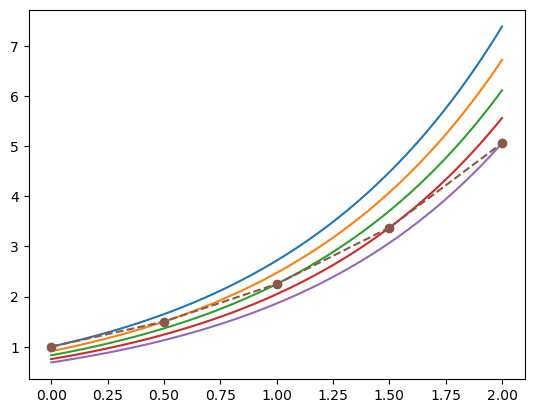

In [84]:
# figure 9.4
def euler_step(f, y, t, h):
    return y + h * f(y, t), t + h


def ode(f, a, b, y, k, step):
    y, t, h = y, a, (b - a) / k
    ts, ys = [t], [y]
    for _ in range(k):
        y, t = step(f, y, t, h)
        ts.append(t)
        ys.append(y)
    return np.array(ts), np.array(ys)


x = np.linspace(0, 2, 101)

ts, ys = ode(lambda y, t: y, 0, 2, 1, 4, step=euler_step)
for t, y in zip(ts, ys):
    plt.plot(x, y / np.exp(t) * np.exp(x))
plt.plot(ts, ys, 'o--')

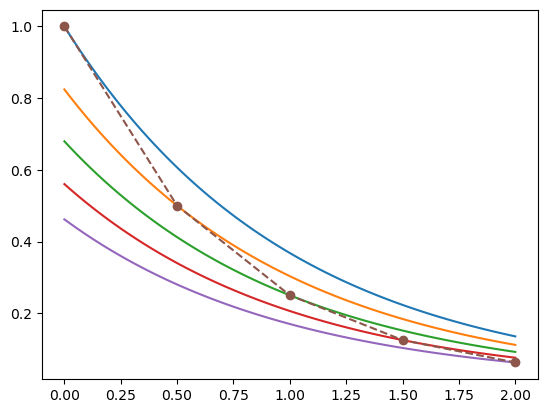

In [85]:
ts, ys = ode(lambda y, t: -y, 0, 2, 1, 4, step=euler_step)
for t, y in zip(ts, ys):
    plt.plot(x, y * np.exp(t) * np.exp(-x))
plt.plot(ts, ys, 'o--')

In [86]:
# example 9.9
def f(y, t):
    return y + .5 * y ** 3 - 1


opt.root_scalar(partial(f, t=0), x0=1)

      converged: True
           flag: converged
 function_calls: 10
     iterations: 5
           root: 0.7709169970592481
         method: newton

In [87]:
y = euler_step(f, 1, 0, .5)[0]
print(y)
opt.root_scalar(partial(f, t=0), x0=y)

1.25


      converged: True
           flag: converged
 function_calls: 10
     iterations: 5
           root: 0.7709169970592481
         method: newton

In [88]:
# 9.10
def f(y, t):
    return - 100 * y + 100 * t + 101

ode(f, 0, .4, .99, 4, step=euler_step)

(array([0. , 0.1, 0.2, 0.3, 0.4]),
 array([  0.99,   1.19,   0.39,   8.59, -64.21]))

In [ ]:
ode(f, 0, .4, 1.01, 4, step=euler_step)

(array([0. , 0.1, 0.2, 0.3, 0.4]), array([ 1.01,  1.01,  2.01, -5.99, 67.01]))

In [ ]:
def backward_euler_step(f, y, t, h):
    def g(z):
        return z - h * f(z, t + h) - y
    return opt.root_scalar(g, x0=euler_step(f, y, t, h)[0]).root, t + h


ode(f, 0, .4, 0, 4, step=backward_euler_step)

(array([0. , 0.1, 0.2, 0.3, 0.4]),
 array([0.      , 1.009091, 1.191736, 1.299249, 1.399932]))

In [ ]:
ode(f, 0, .4, 2, 4, step=backward_euler_step)

(array([0. , 0.1, 0.2, 0.3, 0.4]),
 array([2.      , 1.190909, 1.208264, 1.300751, 1.400068]))

In [ ]:
def fixpoint_backward_euler_step(f, y, t, h):
    return y + h * f(euler_step(f, y, t, h)[0], t + h), t + h

# stiff won't work
ode(f, 0, .4, 0.99, 4, step=fixpoint_backward_euler_step)

(array([0. , 0.1, 0.2, 0.3, 0.4]),
 array([      0.99,       0.19,     -81.61,   -7534.41, -685748.21]))

In [ ]:
# 9.12
def f(y, t):
    return - 2 * t * y ** 2


def heun_step(f, y, t, h):
    k1 = f(y, t)
    k2 = f(*euler_step(f, y, t, h))
    return y + h / 2 * (k1 + k2), t + h


ode(f, 0, .5, 1, 2, step=heun_step)

(array([0.  , 0.25, 0.5 ]), array([1.      , 0.9375  , 0.796946]))

exercises

In [ ]:
# 9.4
# (b)
euler_step(lambda y, t: -5 * y, 1, 0, .5)

(-1.5, 0.5)

In [91]:
# (d)
backward_euler_step(lambda y, t: -5 * y, 1, 0, .5)

(np.float64(0.2857142857142857), 0.5)

In [92]:
np.exp(-5 * .5)

np.float64(0.0820849986238988)

In [93]:
# 9.5
euler_step(lambda y, t: - y, 1, 0, 1)

(0, 1)

In [94]:
backward_euler_step(lambda y, t: - y, 1, 0, 1)

(np.float64(0.5), 1)

In [95]:
np.exp(-1)

np.float64(0.36787944117144233)

In [102]:
# 9.7
def f(y, t):
    return y[::-1]


euler_step(f, np.array([1, 2]), 0, .5)

(array([2. , 2.5]), 0.5)

computer programs

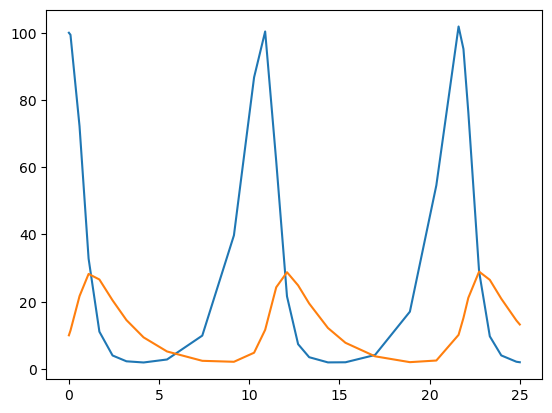

In [ ]:
# 9.1
# (a)
def f(y, t):
    return np.array([
        y[0] * (1 - .1 * y[1]),
        y[1] * (- .5  + .02 * y[0]),
    ])


sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 25], y0=[100, 10])
plt.plot(sol.t, sol.y.T)

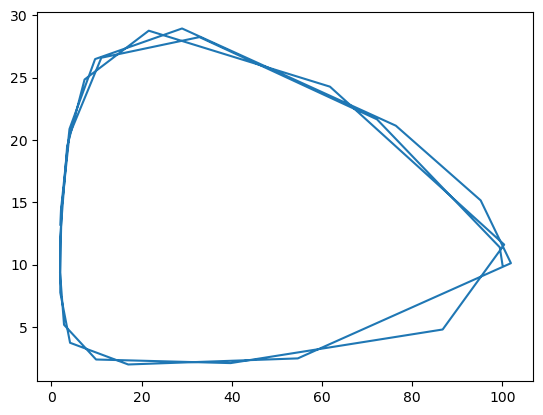

In [115]:
plt.plot(sol.y[0], sol.y[1])

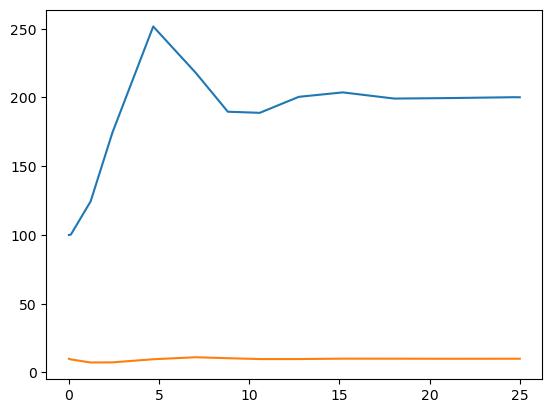

In [ ]:
# (b)
def f(y, t):
    return np.array([
        y[0] * (1 - .1 * y[1]),
        y[1] * (.5 - 10 * y[1] / y[0]),
    ])


sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 25], y0=[100, 10])
plt.plot(sol.t, sol.y.T)

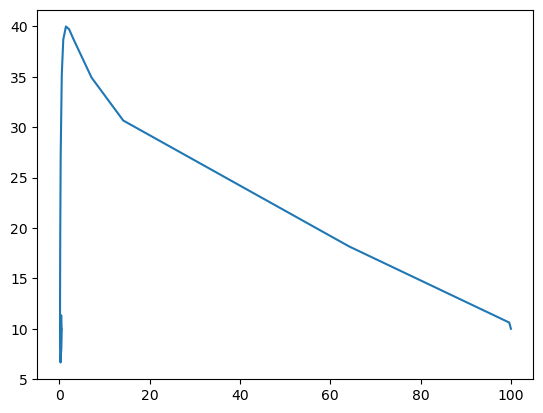

In [112]:
plt.plot(sol.y[0], sol.y[1])

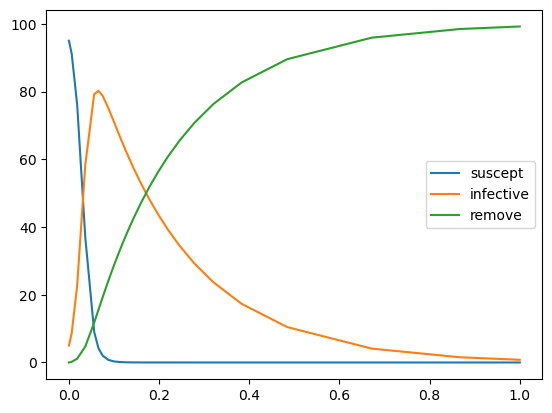

In [121]:
# 9.2
def f(y, t):
    return np.array([
        - y[0] * y[1],
        y[0] * y[1] - 5 * y[1],
        5 * y[1],
    ])


sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 1], y0=[95, 5, 0])
plt.plot(sol.t, sol.y.T, label=['suscept', 'infective', 'remove'])
plt.legend()

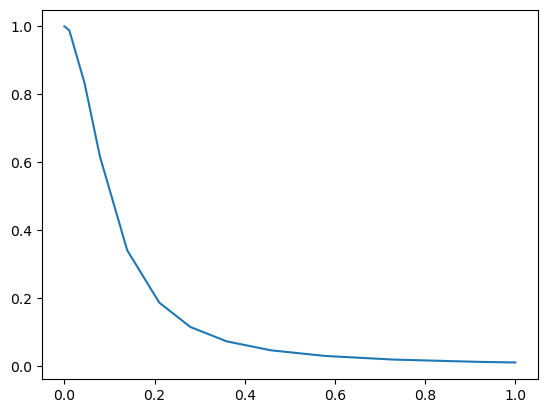

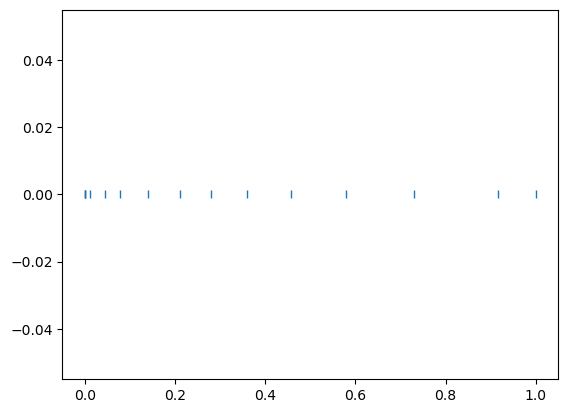

In [125]:
# 9.3
def f(y, t):
    return - 200 * t * y ** 2


sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 1], y0=[1])
plt.plot(sol.t, sol.y.T)
plt.figure()
plt.plot(sol.t, [0] * len(sol.t), '|')

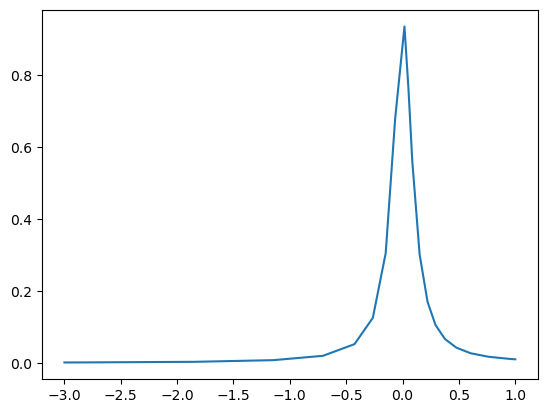

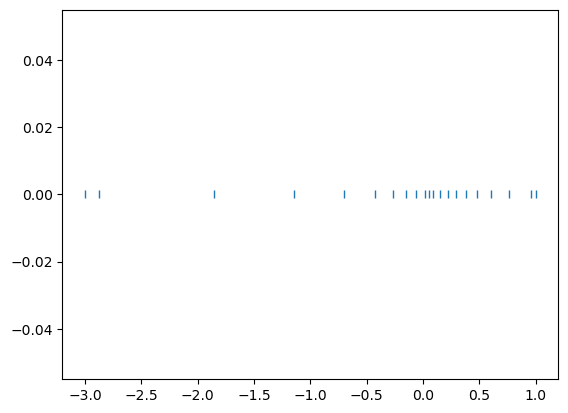

In [126]:
sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[-3, 1], y0=[1/901])
plt.plot(sol.t, sol.y.T)
plt.figure()
plt.plot(sol.t, [0] * len(sol.t), '|')

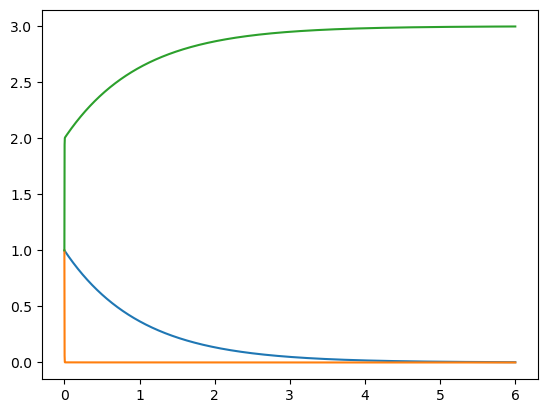

In [129]:
def f(y, t):
    return np.array([
        - y[0],
        y[0] - 1000 * y[1],
        1000 * y[1],
    ])


sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 6], y0=[1, 1, 1])
plt.plot(sol.t, sol.y.T)

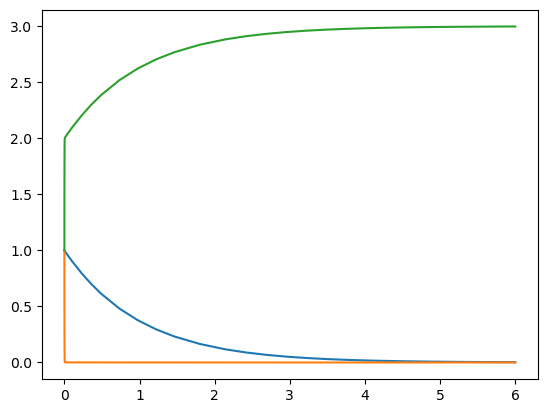

In [132]:
sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, 6], y0=[1, 1, 1], method='BDF')
plt.plot(sol.t, sol.y.T)

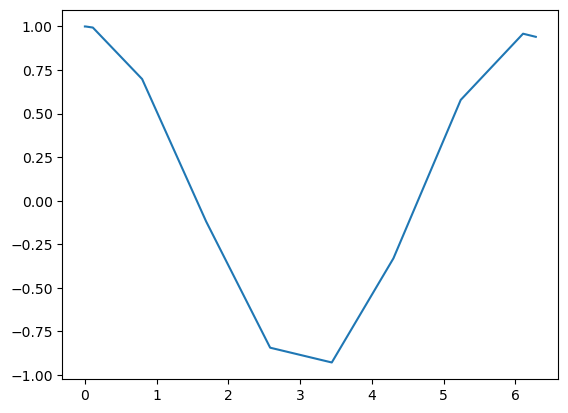

In [133]:
# 9.7
def f(y, t):
    return np.array([
        y[1],
        - y[0] / (y[0] ** 2 + y[2] ** 2) ** (3/2),
        y[3],
        - y[2] / (y[0] ** 2 + y[2] ** 2) ** (3/2),
    ])

e = 0
sol = integrate.solve_ivp(lambda t, y: f(y, t), t_span=[0, np.pi * 2], y0=[
    1 - e, 0, 0, np.sqrt((1 + e) / (1 - e)),
])
plt.plot(sol.t, sol.y[0])

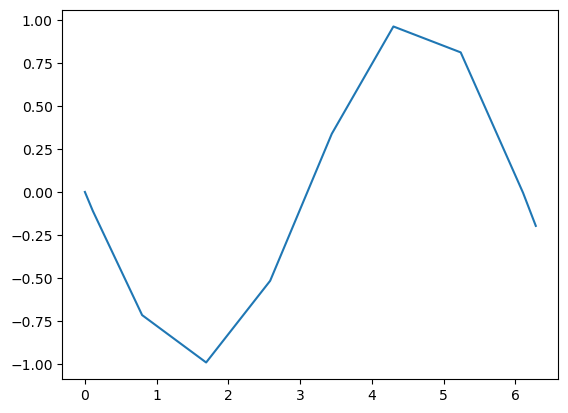

In [134]:
plt.plot(sol.t, sol.y[1])

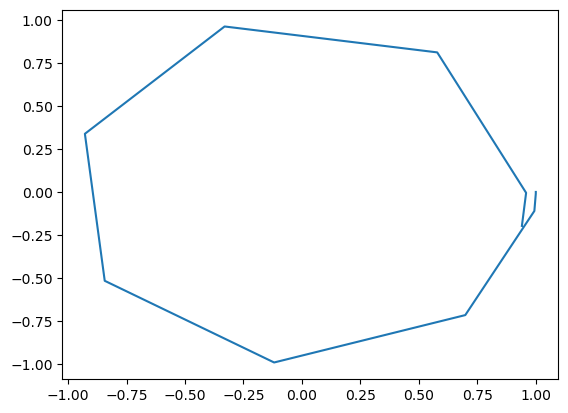

In [135]:
plt.plot(sol.y[0], sol.y[1])

In [136]:
(sol.y[1] ** 2 + sol.y[3] ** 2) / 2 - 1 / np.sqrt(sol.y[0] ** 2 + sol.y[2] ** 2)

array([-0.5     , -0.5     , -0.5     , -0.5     , -0.500332, -0.502772,
       -0.505388, -0.50769 , -0.510397, -0.51607 , -0.519468, -0.519468])

In [137]:
sol.y[0] * sol.y[3] - sol.y[2] * sol.y[1]

array([1.      , 1.      , 1.      , 1.      , 0.999668, 0.997214,
       0.99458 , 0.992299, 0.989676, 0.984264, 0.981041, 0.981041])

In [138]:
# 9.10
def f(x):
    return np.array([
        16 * x[0] ** 4 + 16 * x[1] ** 4 + x[2] ** 4 - 16,
        x[0] ** 2 + x[1] ** 2 + x[2] ** 2 - 3,
        x[0] ** 3 - x[1],
    ])

opt.root(f, x0=[1, 1, 1])

 message: The solution converged.
 success: True
  status: 1
     fun: [ 4.318e-10  8.047e-11 -4.877e-11]
       x: [ 8.780e-01  6.768e-01  1.331e+00]
  method: hybr
    nfev: 16
    fjac: [[-9.975e-01 -5.219e-02 -4.676e-02]
           [-2.824e-02 -3.113e-01  9.499e-01]
           [ 6.413e-02 -9.489e-01 -3.090e-01]]
       r: [-5.101e+01 -2.536e+01 -4.479e+00 -2.283e+00 -7.563e-01
           -1.647e+00]
     qtf: [ 9.724e-09 -4.174e-09 -3.506e-10]

In [149]:
def jac(x):
    return np.array([
        [64 * x[0] ** 3, 64 * x[1] ** 3, 4 * x[2] ** 3],
        [2 * x[0], 2 * x[1], 2 * x[2]],
        [3 * x[0] ** 2, -1, 0],
    ])


def g(y, t):
    return - la.solve(jac(y), f(y))

integrate.solve_ivp(lambda t, y: g(y, t), t_span=[0, 5], y0=[1, 1, 1])

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.369e-01  1.445e+00  2.806e+00  4.381e+00
             5.000e+00]
        y: [[ 1.000e+00  9.905e-01 ...  8.808e-01  8.795e-01]
            [ 1.000e+00  9.718e-01 ...  6.835e-01  6.804e-01]
            [ 1.000e+00  1.037e+00 ...  1.325e+00  1.328e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 32
     njev: 0
      nlu: 0